# Composite Panel MDO

Working notes on `composite_panel` and `optimize_laminate.py`

**Sections:**
1. Material properties  --  what defines a composite ply
2. The Q-bar matrix  --  rotating ply stiffness into a global frame
3. Classical Laminate Theory  --  building the ABD matrix
4. Aerodynamic loads  --  from flight condition to running loads
5. The optimizer  --  minimum-mass laminate design

**Continue with:** multi-case sizing -> `02_tutorial_multicase_sizing.ipynb` | hypersonic + thermal -> `03_tutorial_hypersonic_wing.ipynb` | aeroelastic tailoring -> `04_tutorial_aeroelastic_tailoring.ipynb`


In [1]:
import sys, os
from pathlib import Path

# Resolve repo root robustly regardless of where Jupyter was launched from
_nb_dir = Path(os.path.abspath("")).resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
sys.path.insert(0, str(_repo_root / "src"))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# Dark plot style 
plt.rcParams.update({
    'figure.facecolor': '#0a0e1a',
    'axes.facecolor':   '#0a0e1a',
    'axes.edgecolor':   '#3a4060',
    'axes.labelcolor':  '#e8edf5',
    'xtick.color':      '#e8edf5',
    'ytick.color':      '#e8edf5',
    'text.color':       '#e8edf5',
    'grid.color':       '#3a4060',
    'grid.alpha':       0.5,
})

BLUE  = '#00aaff'; GOLD = '#f0a030'; RED = '#ff4455'
TEAL  = '#00ddbb'; WHITE = '#e8edf5'; DIM = '#3a4060'

print('Setup complete.')

Setup complete.


---
## 1. Material Properties

A unidirectional carbon-epoxy ply is defined by **five elastic constants** and **five strength values**.

### Elastic constants
| Symbol | Meaning | IM7/8552 value |
|--------|---------|----------------|
| E1 | Young's modulus along fibres | 171.4 GPa |
| E2 | Young's modulus ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¥ fibres | 9.08 GPa |
| G12 | In-plane shear modulus | 5.29 GPa |
| nu12 | Major Poisson's ratio | 0.32 |
| nu21 = nu12*E2/E1 | Minor Poisson's ratio | ~0.017 |

### Strength allowables
| Symbol | Meaning | IM7/8552 value |
|--------|---------|----------------|
| F1t | Longitudinal tensile strength | 2326 MPa |
| F1c | Longitudinal compressive strength | 1200 MPa |
| F2t | Transverse tensile strength | 62 MPa |
| F2c | Transverse compressive strength | 200 MPa |
| F12 | In-plane shear strength | 110 MPa |

Notice how **small** F2t is (62 MPa) compared to F1t (2326 MPa). The matrix is the weak link.
We always orient at least some plies off-axis  --  to share transverse loads between fibre directions.

Reference: Hexcel HexPly 8552 product data sheet (2016)

In [2]:
from composite_panel import IM7_8552

mat = IM7_8552()

print('IM7/8552 elastic constants:')
print(f'  E1  = {mat.E1/1e9:.1f} GPa   (fibre direction)')
print(f'  E2  = {mat.E2/1e9:.2f} GPa  (transverse)')
print(f'  G12 = {mat.G12/1e9:.2f} GPa  (in-plane shear)')
print(f'  nu12 = {mat.nu12:.2f}')
print(f'  nu21 = {mat.nu12 * mat.E2 / mat.E1:.4f}  (derived: nu21 = nu12*E2/E1)')
print()
print('Strength allowables:')
print(f'  F1t = {mat.F1t/1e6:.0f} MPa  F1c = {mat.F1c/1e6:.0f} MPa')
print(f'  F2t = {mat.F2t/1e6:.0f} MPa   F2c = {mat.F2c/1e6:.0f} MPa')
print(f'  F12 = {mat.F12/1e6:.0f} MPa')
print()
print(f'Fibre/transverse tensile strength ratio: {mat.F1t/mat.F2t:.0f}x')
print(f'  -> A 0deg ply can carry {mat.F1t/mat.F2t:.0f}x more load along the fibres than across them')

IM7/8552 elastic constants:
  E1  = 171.4 GPa   (fibre direction)
  E2  = 9.08 GPa  (transverse)
  G12 = 5.29 GPa  (in-plane shear)
  nu12 = 0.32
  nu21 = 0.0170  (derived: nu21 = nu12*E2/E1)

Strength allowables:
  F1t = 2326 MPa  F1c = 1200 MPa
  F2t = 62 MPa   F2c = 200 MPa
  F12 = 90 MPa

Fibre/transverse tensile strength ratio: 38x
  -> A 0deg ply can carry 38x more load along the fibres than across them


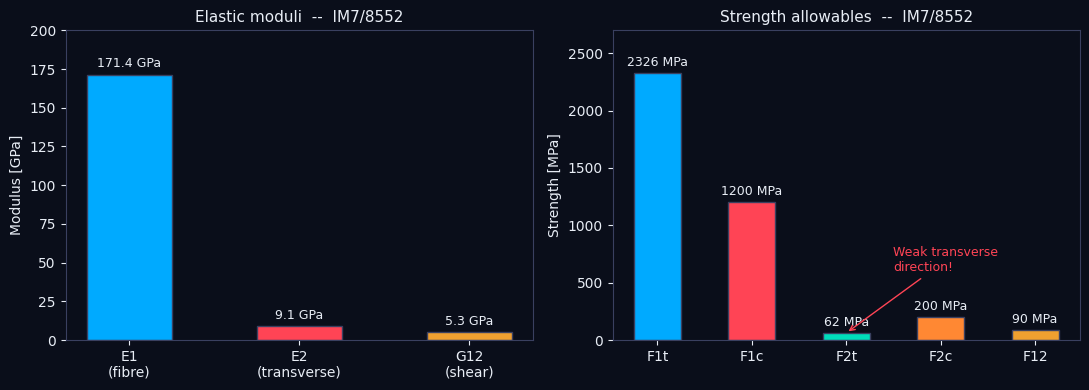

In [3]:
# Visualise the anisotropy ratio  --  how much stiffer is E1 vs E2?
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Stiffness bar chart
ax = axes[0]
names = ['E1\n(fibre)', 'E2\n(transverse)', 'G12\n(shear)']
values = [mat.E1/1e9, mat.E2/1e9, mat.G12/1e9]
colors = [BLUE, RED, GOLD]
bars = ax.bar(names, values, color=colors, edgecolor=DIM, width=0.5)
ax.bar_label(bars, fmt='%.1f GPa', color=WHITE, fontsize=9, padding=3)
ax.set_title('Elastic moduli  --  IM7/8552', fontsize=11)
ax.set_ylabel('Modulus [GPa]')
ax.set_ylim(0, 200)

# Strength bar chart
ax = axes[1]
s_names = ['F1t', 'F1c', 'F2t', 'F2c', 'F12']
s_vals  = [mat.F1t/1e6, mat.F1c/1e6, mat.F2t/1e6, mat.F2c/1e6, mat.F12/1e6]
s_cols  = [BLUE, RED, TEAL, '#ff8833', GOLD]
bars = ax.bar(s_names, s_vals, color=s_cols, edgecolor=DIM, width=0.5)
ax.bar_label(bars, fmt='%.0f MPa', color=WHITE, fontsize=9, padding=3)
ax.set_title('Strength allowables  --  IM7/8552', fontsize=11)
ax.set_ylabel('Strength [MPa]')
ax.set_ylim(0, 2700)
ax.annotate('Weak transverse\ndirection!', xy=(2, mat.F2t/1e6), xytext=(2.5, 600),
            arrowprops=dict(arrowstyle='->', color=RED), color=RED, fontsize=9)

plt.tight_layout()
plt.show()

---
## 2. The Q-Bar Matrix  --  Rotating Ply Stiffness

A single ply oriented at angle **theta** to the laminate x-axis contributes to the laminate stiffness
through its **rotated reduced stiffness matrix Q** (pronounced "Q-bar").

### Why Q and not just Q?

The reduced stiffness matrix **Q** describes a ply's behaviour in its own (1-2) frame:
```
{sigma_1_2} = [Q] {eps_1_2}       (material frame)
```
But in a laminate, all plies share the same global strain (x-y frame). We need Q in the global frame:
```
{sigma_xy} = [Q(theta)] {eps_xy}  (global frame)
```

### The invariant form 

Rather than computing T^-^1QTT^-^1 (which needs a matrix inverse), the code uses the
**Tsai-Pagano invariant form**  --  Q expressed directly as polynomials in cos(theta) and sin(theta):

$$\bar{Q}_{11} = Q_{11}c^4 + 2(Q_{12}+2Q_{66})c^2s^2 + Q_{22}s^4$$
$$\bar{Q}_{22} = Q_{11}s^4 + 2(Q_{12}+2Q_{66})c^2s^2 + Q_{22}c^4$$

Thr invariant form preserves differentiability for optimization. 

Reference: Kassapoglou (2013) Sec.2.4

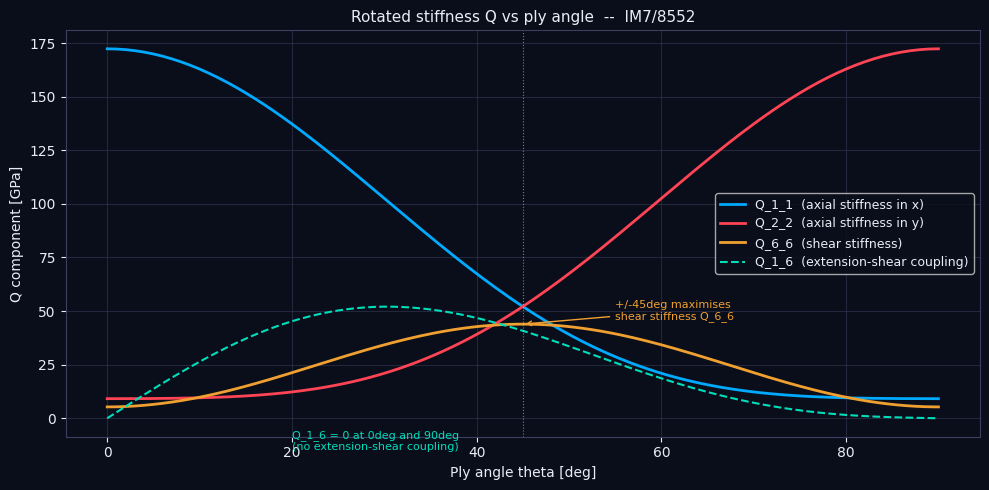

Key observations:
  Q_1_1 at 0deg  = 172.3 GPa  (fibres carry load  --  very stiff)
  Q_1_1 at 90deg = 9.1 GPa  (matrix carries load  --  much softer)
  Q_6_6 peaks at 45deg = 43.9 GPa  (+/-45deg plies provide shear stiffness)
  Q_1_6 = 0 at 0deg and 90deg  (no coupling  --  use balanced +/-theta pairs to keep it small)


In [4]:
# Compute Q for a range of angles and plot key components
# This shows how ply stiffness rotates as you change orientation

from composite_panel.optimizer import _Q_bar_matrix

angles_deg = np.linspace(0, 90, 181)
Qb11, Qb22, Qb12, Qb66, Qb16 = [], [], [], [], []

for theta_deg in angles_deg:
    Qb = _Q_bar_matrix(mat, np.radians(theta_deg))
    Qb11.append(float(Qb[0,0]) / 1e9)
    Qb22.append(float(Qb[1,1]) / 1e9)
    Qb12.append(float(Qb[0,1]) / 1e9)
    Qb66.append(float(Qb[2,2]) / 1e9)
    Qb16.append(float(Qb[0,2]) / 1e9)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(angles_deg, Qb11, color=BLUE,  lw=2, label='Q_1_1  (axial stiffness in x)')
ax.plot(angles_deg, Qb22, color=RED,   lw=2, label='Q_2_2  (axial stiffness in y)')
ax.plot(angles_deg, Qb66, color=GOLD,  lw=2, label='Q_6_6  (shear stiffness)')
ax.plot(angles_deg, Qb16, color=TEAL,  lw=1.5, linestyle='--', label='Q_1_6  (extension-shear coupling)')

ax.axvline(45, color=WHITE, lw=0.8, linestyle=':', alpha=0.5)
ax.annotate('+/-45deg maximises\nshear stiffness Q_6_6', xy=(45, max(Qb66)),
            xytext=(55, max(Qb66)*1.05), color=GOLD, fontsize=8,
            arrowprops=dict(arrowstyle='->', color=GOLD))
ax.annotate('Q_1_6 = 0 at 0deg and 90deg\n(no extension-shear coupling)', xy=(0, 0),
            xytext=(20, -15), color=TEAL, fontsize=8)

ax.set_xlabel('Ply angle theta [deg]')
ax.set_ylabel('Q component [GPa]')
ax.set_title('Rotated stiffness Q vs ply angle  --  IM7/8552', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

print('Key observations:')
print(f'  Q_1_1 at 0deg  = {Qb11[0]:.1f} GPa  (fibres carry load  --  very stiff)')
print(f'  Q_1_1 at 90deg = {Qb11[-1]:.1f} GPa  (matrix carries load  --  much softer)')
print(f'  Q_6_6 peaks at 45deg = {max(Qb66):.1f} GPa  (+/-45deg plies provide shear stiffness)')
print(f'  Q_1_6 = 0 at 0deg and 90deg  (no coupling  --  use balanced +/-theta pairs to keep it small)')

---
## 3. Classical Laminate Theory  --  The ABD Matrix

For a stack of N plies, CLT assembles the individual Q contributions into the **ABD matrix**:

$$\begin{bmatrix} N \\ M \end{bmatrix} = \begin{bmatrix} A & B \\ B & D \end{bmatrix} \begin{bmatrix} \varepsilon_0 \\ \kappa \end{bmatrix}$$

| Matrix | Physical meaning | Formula |
|--------|-----------------|----------|
| **A** | Extensional stiffness | $A_{ij} = \sum_k \bar{Q}_{ij}^{(k)} t_k$ |
| **B** | Bending-extension coupling | $B_{ij} = \sum_k \bar{Q}_{ij}^{(k)} z_{mid,k} t_k$ |
| **D** | Bending stiffness | $D_{ij} = \sum_k \bar{Q}_{ij}^{(k)} (z_{1k}^3 - z_{0k}^3)/3$ |

For **symmetric laminates** (mirror image about mid-plane), **B = 0** exactly  --  membrane loads
don't cause bending, and moments don't cause in-plane strains. This is always enforced in our designs.

Reference: Jones (1999) Sec.4.3

In [5]:
from composite_panel import Ply, Laminate

# Build a quasi-isotropic [+/-45/0/90]s laminate  --  8 plies at 0.125mm each
PLY_T  = 0.125e-3   # 0.125 mm per ply
angles = [-45, 0, 45, 90, 90, 45, 0, -45]   # symmetric stack
plies  = [Ply(mat, PLY_T, a) for a in angles]
lam    = Laminate(plies)

print(lam.summary())
print()

# Check B = 0 for symmetric laminate
B_max = np.max(np.abs(lam.B))
print(f'Max |B| = {B_max:.2e} N  (should be ~0 for symmetric laminate)')
print(f'Total thickness h = {lam.thickness*1e3:.3f} mm')
print(f'Effective Ex = {lam.Ex/1e9:.1f} GPa')
print(f'Effective Ey = {lam.Ey/1e9:.1f} GPa')
print()
print('For a quasi-isotropic laminate, Ex ~= Ey (same stiffness in all directions)')
print(f'  Ratio Ey/Ex = {lam.Ey/lam.Ex:.4f}  (1.000 = perfectly isotropic)')

Laminate  -  8 plies  |  h = 1.000 mm
  Stacking: [-45/0/45/90/90/45/0/-45]

  A matrix [MN/m]:
        71.425      22.229       0.000
        22.229      71.425       0.000
         0.000       0.000      24.598

  D matrix [N*m]:
         7.261       2.456      -1.594
         2.456       3.436      -1.594
        -1.594      -1.594       2.653

Max |B| = 4.55e-13 N  (should be ~0 for symmetric laminate)
Total thickness h = 1.000 mm
Effective Ex = 64.5 GPa
Effective Ey = 64.5 GPa

For a quasi-isotropic laminate, Ex ~= Ey (same stiffness in all directions)
  Ratio Ey/Ex = 1.0000  (1.000 = perfectly isotropic)


In [6]:
# Compare A matrices for different layup families
# This shows how the choice of angles changes extensional stiffness

layups = {
    '[0]_8':           [0,0,0,0,0,0,0,0],
    '[+/-45/0/90]_s':  [-45,0,45,90,90,45,0,-45],    # quasi-isotropic
    '[+/-45]_2s':      [-45,45,-45,45,45,-45,45,-45], # shear-dominated
    '[90]_8':          [90,90,90,90,90,90,90,90],
}

print(f'  {"Layup":<20}  {"Ex [GPa]":>10}  {"Ey [GPa]":>10}  {"A66/A11":>10}')
print('  ' + '-'*55)
for name, ang in layups.items():
    l = Laminate([Ply(mat, PLY_T, a) for a in ang])
    A66_A11 = l.A[2,2] / l.A[0,0]
    print(f'  {name:<20}  {l.Ex/1e9:>10.1f}  {l.Ey/1e9:>10.1f}  {A66_A11:>10.3f}')
print()
print('Notes:')
print('  [0]_8          --  all fibres aligned: max Ex, minimum Ey (very anisotropic)')
print('  [+/-45/0/90]_s --  quasi-isotropic: Ex ~= Ey (use when load direction unknown)')
print('  [+/-45]_2s     --  shear optimised: low Ex, Ey but high A66 shear stiffness')


  Layup                   Ex [GPa]    Ey [GPa]     A66/A11
  -------------------------------------------------------
  [0]_8                      171.4         9.1       0.031
  [+/-45/0/90]_s              64.5        64.5       0.344
  [+/-45]_2s                  19.0        19.0       0.842
  [90]_8                       9.1       171.4       0.579

Notes:
  [0]_8          --  all fibres aligned: max Ex, minimum Ey (very anisotropic)
  [+/-45/0/90]_s --  quasi-isotropic: Ex ~= Ey (use when load direction unknown)
  [+/-45]_2s     --  shear optimised: low Ex, Ey but high A66 shear stiffness


---
## 4. Aerodynamic Loads  --  From Flight Condition to Running Loads

The loads driving structural sizing come from the flight condition.
For **supersonic to hypersonic** speeds, `panel_pressure()` selects the right model:

| Regime | Model | Formula |
|--------|-------|---------|
| Subsonic M < 0.85 | Prandtl-Glauert | DeltaCp = 4alpha / sqrt(1-M^2) |
| Supersonic M 1.15-5 | Oblique shock | Exact Rankine-Hugoniot + expansion |
| Hypersonic M > 5 | Oblique shock | Same  --  naturally extends |

The pressure Deltap is then converted to structural running loads [N/m]:
- **Nyy** = -Deltap x chord/2  (chordwise compression, upper skin)
- **Nxx** = -M_bend / (box height x chord) x cos^2(sweep)  (from elliptic bending moment)
- **Nxy** = 0.15|Nxx| + 0.10|Nyy|  (torsion + sweep  --  empirical)
- **Mxx** = Deltap x chord^2 / 8  (simply-supported panel under uniform pressure)

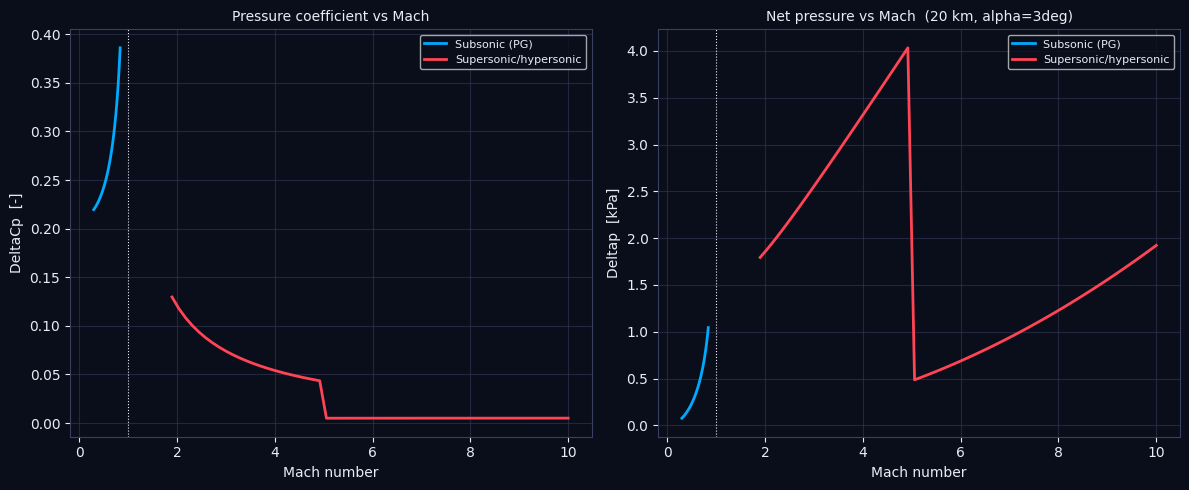

Key physics:
  Subsonic: DeltaCp rises toward M=1 (compressibility amplifies lift per degree AoA)
  Supersonic: DeltaCp falls as M increases (shock angle decreases, weaker pressure jump)
  Deltap peaks near M=1 despite DeltaCp trend  --  because dynamic pressure q grows with M^2


In [7]:
from composite_panel.aero_loads import panel_pressure, _isa

# Show how DeltaCp and Deltap vary with Mach at fixed altitude and alpha
alpha_deg = 3.0
alt_m     = 20_000   # 20 km
rho, a_sound = _isa(alt_m)

machs = np.concatenate([np.linspace(0.3, 0.84, 40), np.linspace(1.9, 10, 60)])
dCp_vals, dp_vals = [], []

for M in machs:
    q = 0.5 * rho * (M * a_sound)**2
    dp = panel_pressure(M, alpha_deg, q)
    dCp_vals.append(dp / q)
    dp_vals.append(dp / 1e3)   # kPa

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, vals, ylabel, title in zip(axes,
    [dCp_vals, dp_vals],
    ['DeltaCp  [-]', 'Deltap  [kPa]'],
    ['Pressure coefficient vs Mach', 'Net pressure vs Mach  (20 km, alpha=3deg)']):
    ax.plot(machs[machs < 1], [v for M,v in zip(machs,vals) if M<1], color=BLUE, lw=2, label='Subsonic (PG)')
    ax.plot(machs[machs > 1], [v for M,v in zip(machs,vals) if M>1], color=RED,  lw=2, label='Supersonic/hypersonic')
    ax.axvline(1.0, color=WHITE, lw=0.8, linestyle=':')
    ax.set_xlabel('Mach number')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

print('Key physics:')
print('  Subsonic: DeltaCp rises toward M=1 (compressibility amplifies lift per degree AoA)')
print('  Supersonic: DeltaCp falls as M increases (shock angle decreases, weaker pressure jump)')
print('  Deltap peaks near M=1 despite DeltaCp trend  --  because dynamic pressure q grows with M^2')

---
## 5. The Optimizer  --  Minimum-Mass Laminate Design

Now we put it all together. `optimize_laminate()` formulates this problem:

$$\min_{t_k} \quad \rho \cdot 2 \sum_k t_k$$

$$\text{subject to:} \quad RF_k(t) \geq RF_{min} \quad \forall k$$
$$\quad\quad\quad\quad\quad t_k \geq t_{min}$$
$$\quad\quad\quad\quad\quad t_i = t_j \quad \text{(balance pairs)}$$

The optimizer is **IPOPT**, an industrial interior-point NLP solver, driven through
**CasADi's automatic differentiation**  --  exact Jacobians and Hessians, not finite differences.

Every step of the CLT + Tsai-Wu calculation is expressed using
`aerosandbox.numpy`  --  a CasADi-backed numpy drop-in. When `t_k` are optimization variables
(CasADi MX symbols), all downstream operations build a **symbolic computation graph**.
IPOPT differentiates through that graph automatically.

In [8]:
from composite_panel.optimizer import optimize_laminate, detect_balance_pairs, supersonic_panel_loads

# Define the half-stack (bottom half of symmetric laminate)
# Full laminate will be [0/+45/-45/90]s = 8 plies
angles_half = [0.0, 45.0, -45.0, 90.0]
pairs = detect_balance_pairs(angles_half)
print(f'Balance pairs detected: {pairs}  (ply {pairs[0][0]} = +45deg paired with ply {pairs[0][1]} = -45deg)')
print()

# Run the optimizer at Mach 1.6, 15km
loads_16 = supersonic_panel_loads(
    mach=1.6, altitude_m=15000, alpha_deg=3.0,
    panel_chord=0.80, panel_span=0.50, n_load=2.5,
)

result = optimize_laminate(
    N_loads         = loads_16.N,
    M_loads         = loads_16.M,
    mat             = mat,
    angles_half_deg = angles_half,
    rf_min          = 1.5,         # require 50% margin on every ply
    t_min           = 0.05e-3,     # 0.05 mm minimum gage
    t_init          = 0.125e-3,    # start from one standard ply
    balance_pairs   = pairs,
    rho_kg_m3       = 1600.0,
    verbose         = False,
)
print(result.summary())

ImportError: cannot import name 'supersonic_panel_loads' from 'composite_panel.optimizer' (C:\Users\AlexanderAmos\Documents\code\composite_panel\src\composite_panel\optimizer.py)

---
## Summary

Here's the full data flow in one diagram:

```
Flight condition (Mach, altitude, alpha, MTOW)
          |
          v  panel_pressure()  +  elliptic bending moment
    running loads  [Nxx, Nyy, Nxy, Mxx]  [N/m]
          |
          |  + N_T, M_T  from thermal_resultants()  (if hot)
          v
    optimize_laminate()
          |
          |--- design variables:  t_k  (ply thicknesses)  [CasADi MX]
          |--- Q_k(theta_k)       ->  rotated ply stiffness
          |--- A(t), D(t)         ->  ABD matrices
          |--- eps_0 = A^-1 N,  kappa = D^-1 M  ->  midplane response
          |--- sigma_1_2,k        ->  ply stresses
          |--- RF_k >= 1.5        ->  Tsai-Wu strength constraint
          |--- minimize rho*2*sum(t_k)  ->  mass objective
          +--- IPOPT (exact AD via CasADi)
                    |
                    v
            t*  ->  OptimizationResult  (h, rhoh, min_RF)
```


---
## 6. Ply-Level Stress and Stacking Trade Study

The optimizer gives us the lightest laminate that satisfies global RF constraints. But it is useful to inspect the **ply-level stresses** and to understand how the choice of off-axis angle affects the governing reserve factor for a given load.

The demo below uses a fixed 8-ply laminate at Mach 1.6 cruise:
- Left column: fibre stress, transverse stress, and Tsai-Wu RF per ply
- Bottom row: governing RF as the off-axis angle sweeps from 0 to 90 deg

The sweep finds the angle that maximises the minimum RF across all plies for this specific load combination -- useful for picking an initial stacking before running the optimizer.

| Parameter | Value |
|-----------|-------|
| Mach | 1.6 |
| Altitude | 15 km |
| Alpha | 3 deg |
| Panel chord x span | 20 cm x 30 cm |
| n_load | 1.0 (cruise) |
| Material | IM7/8552, 0.125 mm/ply |
| Stack | [base/-base/0/90]_s, base = 45 deg |

In [ ]:
from composite_panel import check_laminate
from composite_panel import supersonic_panel_loads

# --- Parameters ---------------------------------------------------------------
mach        = 1.6
alt_m       = 15_000
alpha_deg   = 3.0
panel_chord = 0.20
panel_span  = 0.30
n_load      = 1.0
ply_t       = 0.125e-3
n_plies     = 8
base_angle  = 45.0

# Build [base/-base/0/90]_s laminate
base_pattern = [base_angle, -base_angle, 0, 90]
n_half       = n_plies // 2
half_stack   = [base_pattern[i % 4] for i in range(n_half)]
angles_demo  = half_stack + half_stack[::-1]

plies_demo  = [Ply(mat, ply_t, a) for a in angles_demo]
lam_demo    = Laminate(plies_demo)

# --- Aerodynamic loads --------------------------------------------------------
loads_demo = supersonic_panel_loads(
    mach=mach, altitude_m=alt_m, alpha_deg=alpha_deg,
    panel_chord=panel_chord, panel_span=panel_span, n_load=n_load,
)
print(f'Panel loads at Mach {mach}, {alt_m/1e3:.0f} km, alpha={alpha_deg}deg, n={n_load}g:')
print(f'  {loads_demo}')
print()

# --- CLT response + Tsai-Wu failure check ------------------------------------
res_demo  = lam_demo.response(N=loads_demo.N, M=loads_demo.M)
results   = check_laminate(res_demo, plies_demo, criterion='tsai_wu', verbose=False)

n_pass = sum(1 for r in results if r.rf >= 1.5)
n_marg = sum(1 for r in results if 1.0 <= r.rf < 1.5)
n_fail = sum(1 for r in results if r.rf < 1.0)
gov_rf = min(r.rf for r in results)
print(f'Layup {angles_demo}')
print(f'Summary: {n_pass}/{n_plies} plies meet RF >= 1.5  |  {n_marg} marginal  |  '
      f'{n_fail} failed  |  governing RF = {gov_rf:.2f}')

# --- Stacking trade study: sweep off-axis angle -------------------------------
sweep_angles = np.arange(0, 91, 5)
governing_rf_sweep = []
for theta in sweep_angles:
    pat  = [theta, -theta, 0, 90]
    half = [pat[i % 4] for i in range(n_half)]
    stk  = half + half[::-1]
    p    = [Ply(mat, ply_t, a) for a in stk]
    l    = Laminate(p)
    r    = l.response(N=loads_demo.N, M=loads_demo.M)
    fail = check_laminate(r, p, criterion='tsai_wu', verbose=False)
    governing_rf_sweep.append(min(f.rf for f in fail))

governing_rf_sweep = np.array(governing_rf_sweep)
opt_idx = np.argmax(governing_rf_sweep)
print(f'Best off-axis angle: {sweep_angles[opt_idx]} deg  ->  governing RF = {governing_rf_sweep[opt_idx]:.2f}')

Panel loads at Mach 1.6, 15 km, alpha=3.0deg, n=1.0g:
  PanelLoads  Nxx=-0.2 kN/m  Nyy=-0.4 kN/m  Nxy=+0.1 kN/m

Layup [45.0, -45.0, 0, 90, 90, 0, -45.0, 45.0]
Summary: 8/8 plies meet RF >= 1.5  |  0 marginal  |  0 failed  |  governing RF = 3.55
Best off-axis angle: 0 deg  ->  governing RF = 13.20


Figure saved -> C:\Users\AlexanderAmos\Documents\code\composite_panel\outputs\supersonic_panel_analysis.png


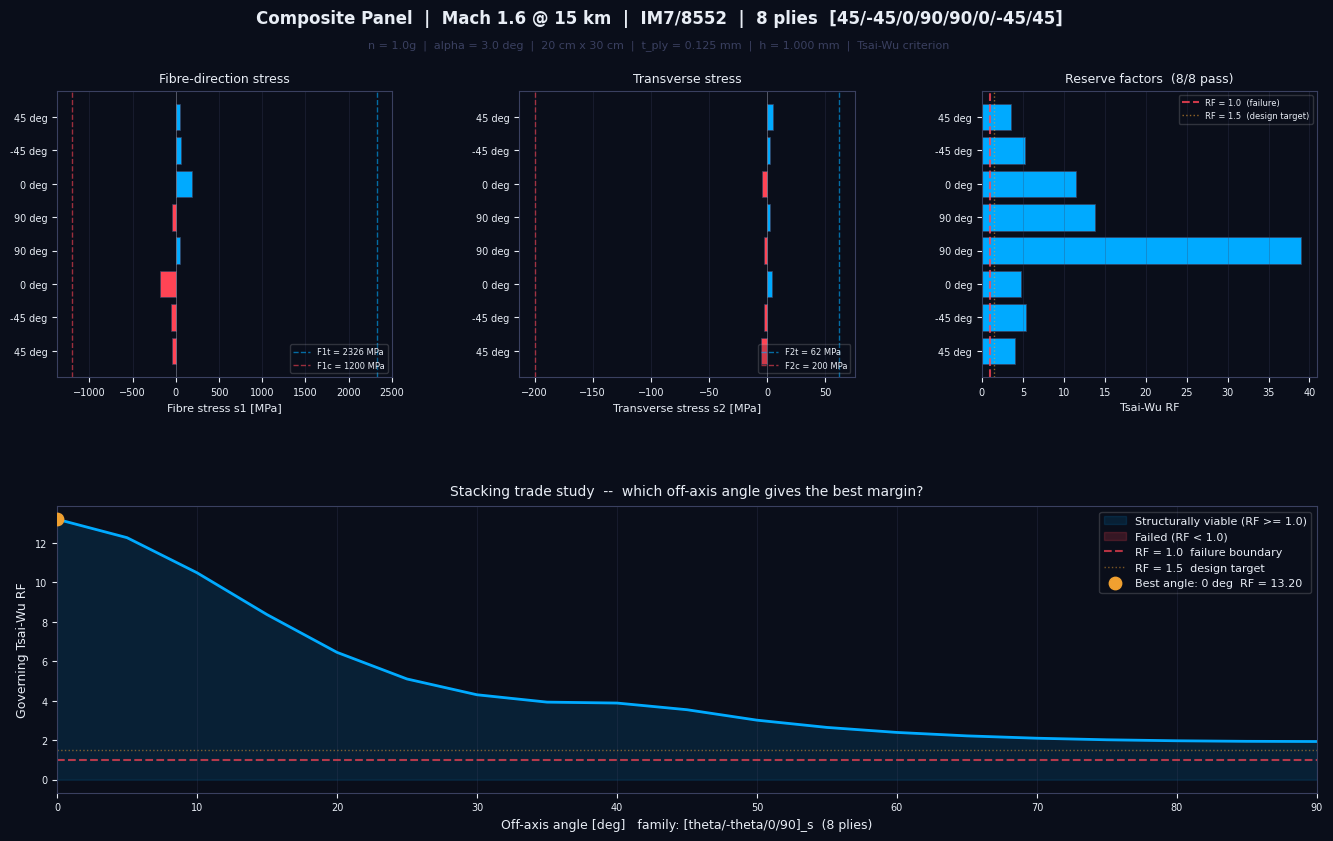

In [ ]:
bg    = '#0a0e1a'; white = '#e8edf5'; dim = '#3a4060'
blue  = '#00aaff'; gold  = '#f0a030'; red = '#ff4455'

def _style_ax(ax):
    ax.set_facecolor(bg)
    ax.tick_params(colors=white, labelsize=7)
    ax.xaxis.label.set_color(white)
    for spine in ax.spines.values():
        spine.set_edgecolor(dim)
    ax.grid(axis='x', color=dim, linewidth=0.4, alpha=0.5)

import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 9), facecolor=bg)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38,
                        left=0.07, right=0.97, top=0.88, bottom=0.10)

ply_labels = [f'{int(a)} deg' for a in angles_demo]

# Panel A: fibre stress
ax1   = fig.add_subplot(gs[0, 0])
sig1  = [res_demo['ply_stress_12'][k][0] / 1e6 for k in range(len(plies_demo))]
cols1 = [red if s < 0 else blue for s in sig1]
ax1.barh(range(len(plies_demo)), sig1, color=cols1, edgecolor=dim, linewidth=0.5)
ax1.axvline(0,             color=white, linewidth=0.5, alpha=0.4)
ax1.axvline( mat.F1t/1e6,  color=blue, linewidth=1, linestyle='--', alpha=0.6,
             label=f'F1t = {mat.F1t/1e6:.0f} MPa')
ax1.axvline(-mat.F1c/1e6,  color=red,  linewidth=1, linestyle='--', alpha=0.6,
             label=f'F1c = {mat.F1c/1e6:.0f} MPa')
ax1.set_yticks(range(len(plies_demo))); ax1.set_yticklabels(ply_labels, fontsize=7)
ax1.set_xlabel('Fibre stress s1 [MPa]', color=white, fontsize=8)
ax1.set_title('Fibre-direction stress', color=white, fontsize=9, pad=6)
ax1.legend(fontsize=6, loc='lower right', framealpha=0.2, labelcolor=white)
_style_ax(ax1)

# Panel B: transverse stress
ax2   = fig.add_subplot(gs[0, 1])
sig2  = [res_demo['ply_stress_12'][k][1] / 1e6 for k in range(len(plies_demo))]
cols2 = [red if s < 0 else blue for s in sig2]
ax2.barh(range(len(plies_demo)), sig2, color=cols2, edgecolor=dim, linewidth=0.5)
ax2.axvline(0,             color=white, linewidth=0.5, alpha=0.4)
ax2.axvline( mat.F2t/1e6,  color=blue, linewidth=1, linestyle='--', alpha=0.6,
             label=f'F2t = {mat.F2t/1e6:.0f} MPa')
ax2.axvline(-mat.F2c/1e6,  color=red,  linewidth=1, linestyle='--', alpha=0.6,
             label=f'F2c = {mat.F2c/1e6:.0f} MPa')
ax2.set_yticks(range(len(plies_demo))); ax2.set_yticklabels(ply_labels, fontsize=7)
ax2.set_xlabel('Transverse stress s2 [MPa]', color=white, fontsize=8)
ax2.set_title('Transverse stress', color=white, fontsize=9, pad=6)
ax2.legend(fontsize=6, loc='lower right', framealpha=0.2, labelcolor=white)
_style_ax(ax2)

# Panel C: reserve factors
ax3       = fig.add_subplot(gs[0, 2])
rfs       = [r.rf for r in results]
bar_cols3 = [red if rf < 1.0 else (gold if rf < 1.5 else blue) for rf in rfs]
ax3.barh(range(len(plies_demo)), rfs, color=bar_cols3, edgecolor=dim, linewidth=0.5)
ax3.axvline(1.0, color=red,  linewidth=1.5, linestyle='--', alpha=0.8, label='RF = 1.0  (failure)')
ax3.axvline(1.5, color=gold, linewidth=1.0, linestyle=':',  alpha=0.6, label='RF = 1.5  (design target)')
ax3.set_yticks(range(len(plies_demo))); ax3.set_yticklabels(ply_labels, fontsize=7)
ax3.set_xlabel('Tsai-Wu RF', color=white, fontsize=8)
ax3.set_title(f'Reserve factors  ({n_pass}/{n_plies} pass)', color=white, fontsize=9, pad=6)
ax3.legend(fontsize=6, framealpha=0.2, labelcolor=white)
_style_ax(ax3)

# Panel D: stacking trade
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(sweep_angles, governing_rf_sweep, color=blue, linewidth=2.0)
ax4.fill_between(sweep_angles, 0, governing_rf_sweep,
                 where=(governing_rf_sweep >= 1.0), alpha=0.12, color=blue,
                 label='Structurally viable (RF >= 1.0)')
ax4.fill_between(sweep_angles, 0, governing_rf_sweep,
                 where=(governing_rf_sweep < 1.0),  alpha=0.18, color=red,
                 label='Failed (RF < 1.0)')
ax4.axhline(1.0, color=red,  linewidth=1.5, linestyle='--', alpha=0.7, label='RF = 1.0  failure boundary')
ax4.axhline(1.5, color=gold, linewidth=1.0, linestyle=':',  alpha=0.5, label='RF = 1.5  design target')
ax4.scatter(sweep_angles[opt_idx], governing_rf_sweep[opt_idx], color=gold, s=80, zorder=5,
            label=f'Best angle: {sweep_angles[opt_idx]} deg  RF = {governing_rf_sweep[opt_idx]:.2f}')
ax4.set_xlabel(f'Off-axis angle [deg]   family: [theta/-theta/0/90]_s  ({n_plies} plies)',
               color=white, fontsize=9)
ax4.set_ylabel('Governing Tsai-Wu RF', color=white, fontsize=9)
ax4.set_title('Stacking trade study  --  which off-axis angle gives the best margin?',
              color=white, fontsize=10, pad=8)
ax4.legend(fontsize=8, framealpha=0.2, labelcolor=white)
ax4.set_xlim(0, 90)
_style_ax(ax4)

fig.text(0.5, 0.955,
         f'Composite Panel  |  Mach {mach} @ {alt_m/1e3:.0f} km  |  {mat.name}  |  '
         f'{n_plies} plies  [{"/".join(str(int(a)) for a in angles_demo)}]',
         ha='center', color=white, fontsize=12, fontweight='bold')
fig.text(0.5, 0.928,
         f'n = {n_load}g  |  alpha = {alpha_deg} deg  |  '
         f'{panel_chord*100:.0f} cm x {panel_span*100:.0f} cm  |  '
         f't_ply = {ply_t*1e3:.3f} mm  |  h = {lam_demo.thickness*1e3:.3f} mm  |  Tsai-Wu criterion',
         ha='center', color=dim, fontsize=8)

out = os.path.join(_repo_root, 'outputs', 'supersonic_panel_analysis.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=bg)
print(f'Figure saved -> {out}')
plt.show()